# Phase 6 — SHAP Explainability
## Zimbabwe Real Estate Price Prediction System


In [1]:
import os
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

warnings.filterwarnings('ignore')


In [3]:
# ----------------------------------------------------------------------
# 1. Setup
# ----------------------------------------------------------------------
FIG_DIR = 'reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans'
})

RANDOM_STATE = 42

def save_figure(name):
    """Save current matplotlib figure and show it."""
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Setup complete. SHAP version:', shap.__version__)


Setup complete. SHAP version: 0.52.0


In [4]:
# ----------------------------------------------------------------------
# 2. Load Data & Model
# ----------------------------------------------------------------------
# Load feature-engineered dataset
PATHS = [
    'data/processed/properties_features.csv',
    'data/processed/properties_clean.csv',
    'property_phase1_engineered.csv',
]
df = None
for p in PATHS:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f'Loaded: {p}  ({df.shape[0]:,} rows x {df.shape[1]} cols)')
        break
if df is None:
    raise FileNotFoundError('Run Phase 2 + 3 notebooks first to generate properties_features.csv')

# Load model metadata to get feature list
with open('models/model_metadata.json', 'r') as f:
    metadata = json.load(f)
SAFE_FEATURES = metadata['features']
print(f'Loaded {len(SAFE_FEATURES)} features from metadata')

# Add log_price if missing
if 'log_price' not in df.columns:
    df['log_price'] = np.log1p(df['price'])

# Ensure all features exist and fill missing values
missing_feats = [f for f in SAFE_FEATURES if f not in df.columns]
if missing_feats:
    print(f'WARNING - Missing features: {missing_feats}')
    SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]

for col in SAFE_FEATURES:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Build X and y
X = df[SAFE_FEATURES].copy()
y = df['log_price'].copy()

# Load trained model
model = joblib.load('models/xgb_tuned.pkl')
print('Loaded model: models/xgb_tuned.pkl')

# Train/test split (same as Phase 5)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]:,} rows, Test: {X_test.shape[0]:,} rows')


Loaded: data/processed/properties_features.csv  (1,985 rows x 53 cols)
Loaded 25 features from metadata
Loaded model: models/xgb_tuned.pkl
Train: 1,588 rows, Test: 397 rows


In [5]:
# ----------------------------------------------------------------------
# 3. Compute SHAP Values
# ----------------------------------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)   # shape (n_samples, n_features)
shap_values_first = shap_values[0]
base_value = explainer.expected_value

print(f'SHAP values computed: {shap_values.shape}')
print(f'Base value (expected log_price): {base_value:.4f}')

SHAP values computed: (397, 25)
Base value (expected log_price): 12.2786


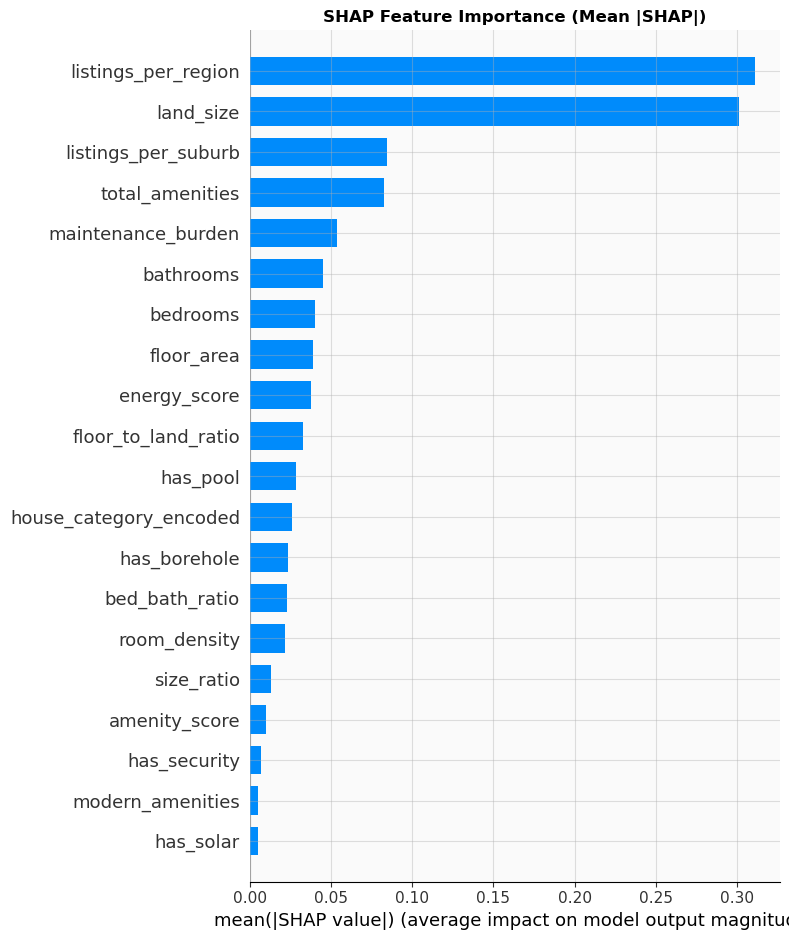

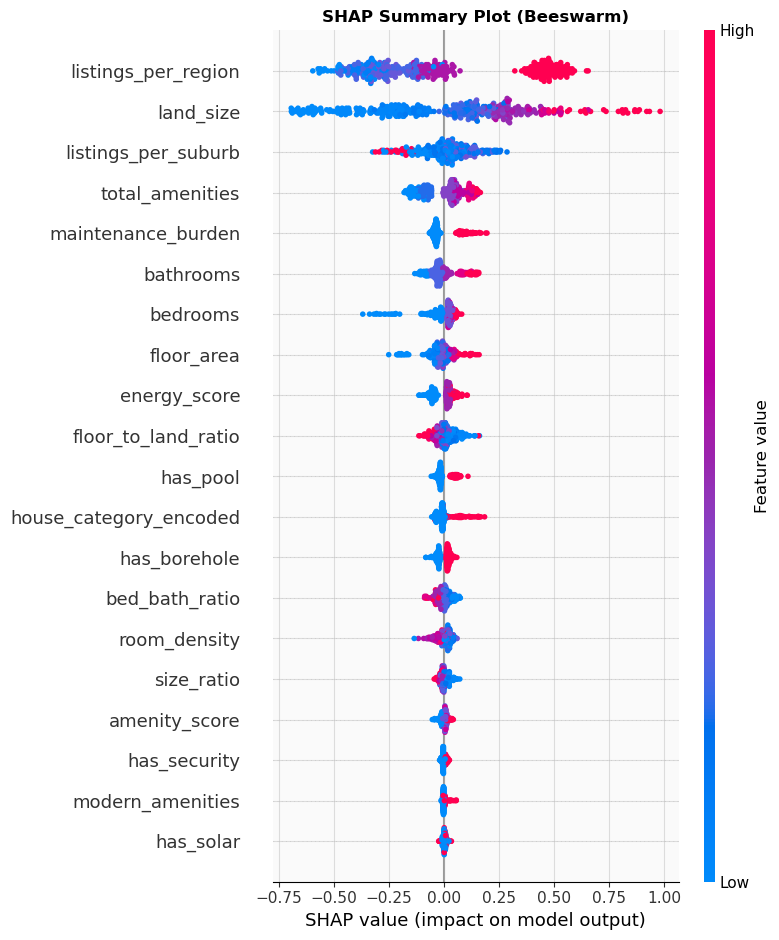

In [6]:
# ----------------------------------------------------------------------
# 4. Global Explanations
# ----------------------------------------------------------------------
# 4.1 Bar plot (mean |SHAP|)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontweight='bold')
plt.tight_layout()
save_figure('40_shap_bar_plot')

# 4.2 Summary (beeswarm) plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm)', fontweight='bold')
plt.tight_layout()
save_figure('41_shap_summary_plot')


Top 5 features by SHAP importance: ['listings_per_region', 'land_size', 'listings_per_suburb', 'total_amenities', 'maintenance_burden']


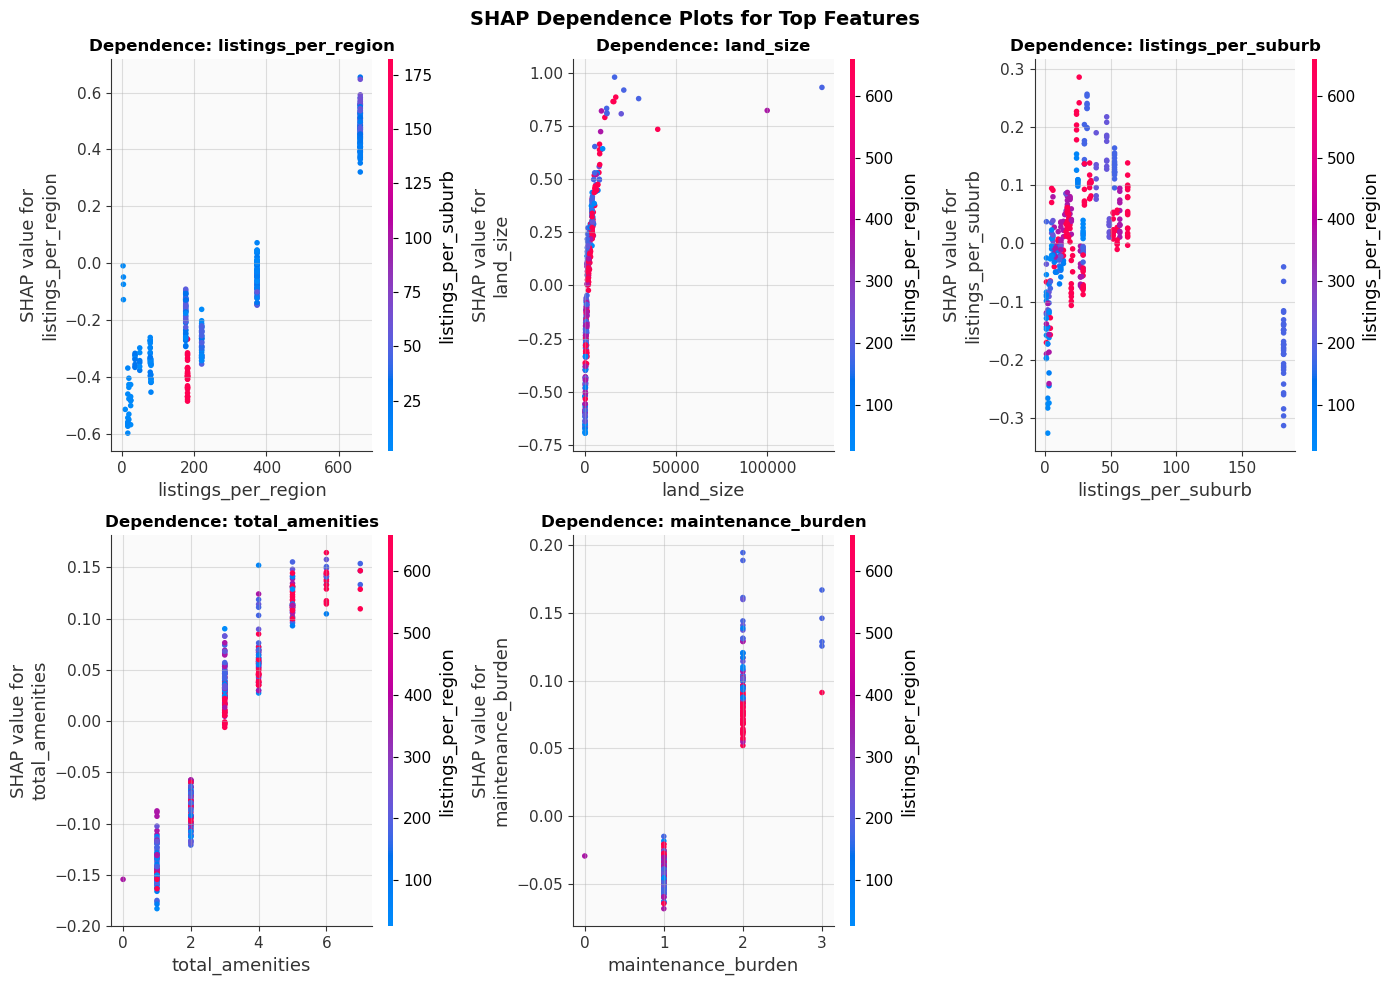

In [7]:
# ----------------------------------------------------------------------
# 5. Dependence Plots (Top Features)
# ----------------------------------------------------------------------
top_n = 5
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-top_n:][::-1]
top_features = [X_test.columns[i] for i in top_idx]
print(f'Top {top_n} features by SHAP importance: {top_features}')

fig, axes = plt.subplots(2, (top_n+1)//2, figsize=(14, 10))
axes = axes.flatten()
for i, feature in enumerate(top_features):
    ax = axes[i]
    shap.dependence_plot(feature, shap_values, X_test, ax=ax, show=False)
    ax.set_title(f'Dependence: {feature}', fontweight='bold')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('SHAP Dependence Plots for Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure('42_shap_dependence_plots')


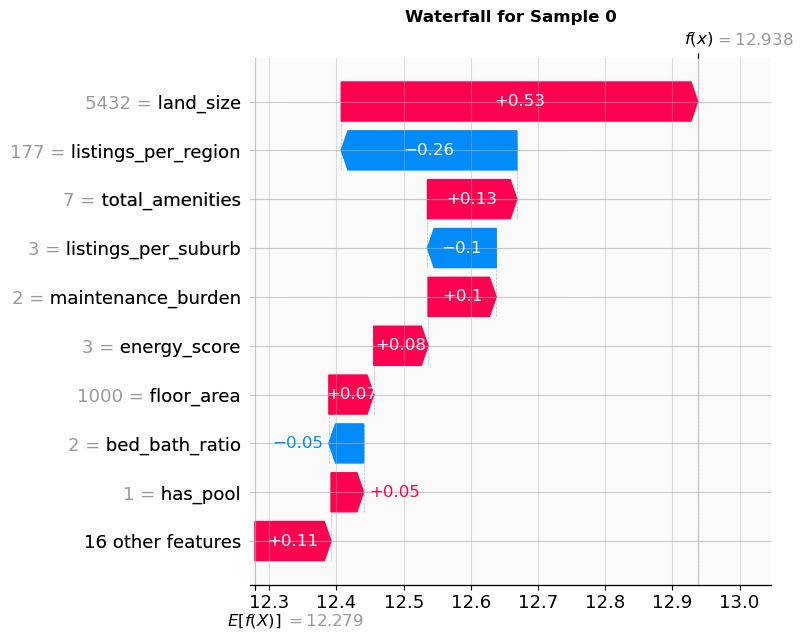

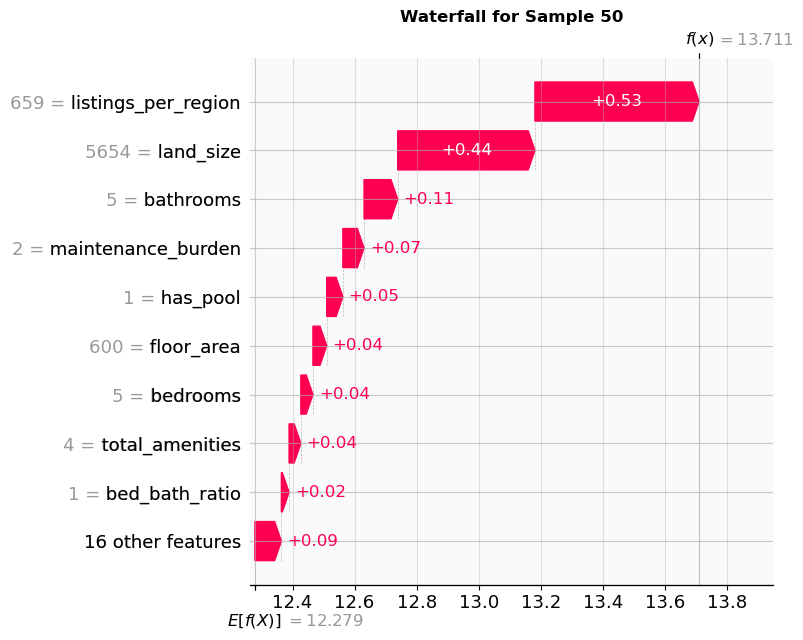

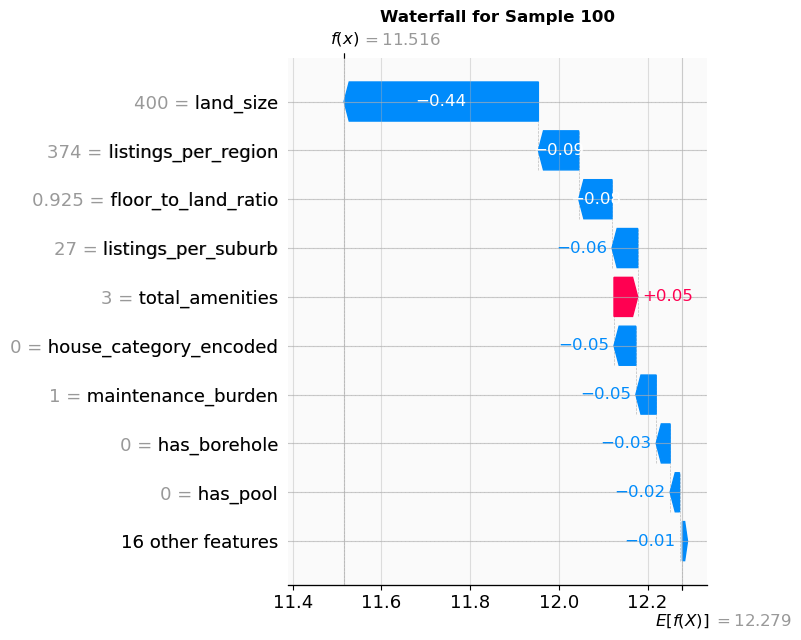

In [9]:
# ----------------------------------------------------------------------
# 6. Local Explanations (Waterfall Plots)
# ----------------------------------------------------------------------
sample_indices = [0, 50, 100]   # choose three different rows

for idx in sample_indices:
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx].values,
            feature_names=X_test.columns.tolist()
        ),
        show=False
    )
    plt.title(f'Waterfall for Sample {idx}', fontweight='bold')
    plt.tight_layout()
    save_figure(f'43_shap_waterfall_sample_{idx}')

In [10]:
# ----------------------------------------------------------------------
# 7. Summary
# ----------------------------------------------------------------------
print('\n--- SHAP Explainability Complete ---')
print('Generated files:')
for name in ['40_shap_bar_plot', '41_shap_summary_plot',
             '42_shap_dependence_plots', '43_shap_waterfall_plots']:
    print(f'  - reports/figures/{name}.png')


--- SHAP Explainability Complete ---
Generated files:
  - reports/figures/40_shap_bar_plot.png
  - reports/figures/41_shap_summary_plot.png
  - reports/figures/42_shap_dependence_plots.png
  - reports/figures/43_shap_waterfall_plots.png
